# Paper Replication: Khan et al. 2026 — PPG-Based Non-Invasive Blood Glucose Estimation

**Paper:** Photoplethysmography based non-invasive blood glucose estimation using statistical, waveform and APG derivative features with machine learning regression  
**Journal:** Frontiers in Digital Health, 2026  
**DOI:** [10.3389/fdgth.2026.1705086](https://doi.org/10.3389/fdgth.2026.1705086)  
**Applied to:** GlucoSense primary dataset — Nigerian T2DM cohort (primary data collection)

---

## Paper Summary

| Item | Original Paper | Our Dataset |
|---|---|---|
| Subjects | 80 (Pakistani, 18–50 yrs) | Nigerian T2DM patients |
| Recordings | 160 (fasting + postprandial) | 73 (fasting / 1hr-PP / 2hr-PP) |
| Sensor | SparkFun Pulse Sensor, green LED 565 nm | Custom PPG sensor |
| Sampling rate | ~127 Hz | 50 Hz |
| Signal duration | 15 s per recording | 70 s per recording |
| Glucose range | 65–160 mg/dL | 73–394 mg/dL (T2DM) |
| Glucometer | Capillary finger-prick | Accu-Chek Active (invasive) |

## Pipeline Overview

1. **Preprocessing** — Detrend → 2nd-order Butterworth bandpass (0.5–5 Hz)
2. **Segmentation** — Moving-window peak/valley detection → 3 consecutive pulses
3. **Feature Extraction** — 35 features from PPG, VPG (1st derivative), APG (2nd derivative):
   - Statistical: Min, Max, RMS, Energy, Mean, SD, Variance
   - Waveform: Systolic Peak, Diastolic Peak, Inter-Peak Interval, Pulse Width, Pulse Rate, Trough Interval
   - APG ratios: b/a, c/a, d/a, e/a, (b-c-d-e)/a, (b-e)/a, (b-c-d)/a, (c+d-b)/a
4. **Feature selection** — Pearson correlation heatmap → 9 shortlisted features
5. **Feature engineering** — 6 composite features (Max_avg, Mean_avg, PeakRatio, SD_avg, Var_avg, SDmean) → **15 final features**
6. **Scaling** — Min-Max normalisation
7. **Models** — DT, XGBoost, KNN, RF (best in paper: R²=0.92, MAE=4.8 mg/dL), SVM
8. **Evaluation** — Paper uses 50/50 random split

## Three-Scheme Evaluation (our scientific contribution)

| Scheme | Strategy | What it tells us |
|---|---|---|
| 1 | 50/50 random split (paper's method) | Paper-comparable result |
| 2 | 5-fold KFold | Randomised CV across all data |
| **3** | **GroupKFold (subject-independent)** | **Honest generalisation** |

> **Why Scheme 3 matters:** The original paper almost certainly has subject-level data leakage in its 50/50 random split (same person's fasting + postprandial readings may split across train and test, but their physiological signature leaks). Our GroupKFold ensures no participant appears in both train and test folds.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.signal import butter, filtfilt, detrend, find_peaks
from scipy.stats import pearsonr
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
import os
import json

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Signal Parameters (our dataset) ──────────────────────────────────────────
SAMPLING_RATE    = 50       # Hz (GlucoSense dataset)
SIGNAL_DURATION  = 70       # seconds total per recording
TRIM_SECONDS     = 5        # seconds to trim from each end
USABLE_SECONDS   = SIGNAL_DURATION - 2 * TRIM_SECONDS  # 60 s
USABLE_SAMPLES   = SAMPLING_RATE * USABLE_SECONDS      # 3000

# ── Butterworth bandpass (paper: 0.5–5 Hz, order 2) ──────────────────────────
BUTTER_ORDER     = 2
BUTTER_LOW_HZ    = 0.5
BUTTER_HIGH_HZ   = 5.0

# ── Pulse segmentation (paper: 3 consecutive pulses) ─────────────────────────
N_PULSES         = 3        # number of pulses to extract per recording

# ── HR-based window for moving-window segmentation ───────────────────────────
HR_MIN_BPM       = 60       # heart rate lower bound
HR_MAX_BPM       = 100      # heart rate upper bound
# window in samples = (SR / BPM) * 60 => 1 cardiac cycle
MIN_PULSE_SAMPLES = int(SAMPLING_RATE * 60 / HR_MAX_BPM)  # shortest cycle
MAX_PULSE_SAMPLES = int(SAMPLING_RATE * 60 / HR_MIN_BPM)  # longest cycle

# ── ML / CV ───────────────────────────────────────────────────────────────────
N_SPLITS   = 5
TEST_SIZE  = 0.50   # paper uses 50/50 split

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH    = 'data/real/glucosense_r_dataset_2026-09-04.csv'
RESULTS_DIR  = 'results'
FIGURES_DIR  = 'figures'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Configuration loaded.")
print(f"  Sampling rate    : {SAMPLING_RATE} Hz")
print(f"  Signal duration  : {SIGNAL_DURATION}s (trim {TRIM_SECONDS}s each end → {USABLE_SECONDS}s usable)")
print(f"  Butterworth      : order={BUTTER_ORDER}, passband={BUTTER_LOW_HZ}–{BUTTER_HIGH_HZ} Hz")
print(f"  N pulses         : {N_PULSES}")
print(f"  HR window        : {HR_MIN_BPM}–{HR_MAX_BPM} BPM")
print(f"  Pulse sample range: {MIN_PULSE_SAMPLES}–{MAX_PULSE_SAMPLES} samples")
print(f"  Test size        : {int(TEST_SIZE*100)}% (paper: 50/50)")
print(f"  CV splits        : {N_SPLITS}")


Configuration loaded.
  Sampling rate    : 50 Hz
  Signal duration  : 70s (trim 5s each end → 60s usable)
  Butterworth      : order=2, passband=0.5–5.0 Hz
  N pulses         : 3
  HR window        : 60–100 BPM
  Pulse sample range: 30–50 samples
  Test size        : 50% (paper: 50/50)
  CV splits        : 5


## 1. Data Loading
Load the GlucoSense primary dataset and parse raw PPG signals.

In [4]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Raw dataset shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
print()

recordings = []
parse_errors = []

for idx, row in df_raw.iterrows():
    try:
        ppg_str = row['ppg_data']
        ppg_full = np.array([float(x) for x in ppg_str.split(';') if x.strip()])

        # Trim first/last TRIM_SECONDS seconds
        trim_n = TRIM_SECONDS * SAMPLING_RATE
        ppg_trimmed = ppg_full[trim_n: trim_n + USABLE_SAMPLES]

        recordings.append({
            'session_id'     : row['session_id'],
            'participant_id' : row['participant_id'],
            'bgl_mgdl'       : float(row['bgl_mgdl']),
            'ppg_raw'        : ppg_full,
            'ppg_trimmed'    : ppg_trimmed,
            'n_samples'      : len(ppg_trimmed),
            'age'            : row.get('age', np.nan),
            'gender'         : row.get('gender', np.nan),
            'session_kind'   : row.get('session_kind', np.nan),
        })
    except Exception as e:
        parse_errors.append({'session_id': row.get('session_id', idx), 'reason': str(e)})

print(f"Total recordings loaded : {len(recordings)}")
print(f"Unique participants     : {len(set(r['participant_id'] for r in recordings))}")
print(f"Parse errors            : {len(parse_errors)}")

bgls = np.array([r['bgl_mgdl'] for r in recordings])
print(f"\nBGL stats — mean={bgls.mean():.1f}, std={bgls.std():.1f}, "
      f"min={bgls.min():.0f}, max={bgls.max():.0f} mg/dL")

session_kinds = pd.Series([r['session_kind'] for r in recordings])
print(f"\nSession kinds:\n{session_kinds.value_counts().to_string()}")


Raw dataset shape: (73, 13)
Columns: ['session_id', 'created_at', 'participant_id', 'age', 'gender', 'weight_kg', 'height_cm', 'years_on_t2dm', 'medication', 'session_kind', 'bgl_mgdl', 'ppg_samples_count', 'ppg_data']

Total recordings loaded : 73
Unique participants     : 63
Parse errors            : 0

BGL stats — mean=151.5, std=54.8, min=73, max=394 mg/dL

Session kinds:
fasting              40
2hr_post_prandial    22
1hr_post_prandial    11


## 2. Preprocessing (Paper's Pipeline)

### Step 1 — Detrend
Remove baseline drift and low-frequency respiration-induced variations.  
`scipy.signal.detrend` (linear detrending) mirrors the paper's MATLAB `detrend` function.

### Step 2 — Butterworth Bandpass (0.5–5 Hz, order 2)
Remove high-frequency noise and residual baseline drift.  
The paper selected 0.5–5 Hz based on the spectrogram of unfiltered signals.  
Uses `filtfilt` (zero-phase) to avoid phase distortion, matching MATLAB's `filtfilt`.


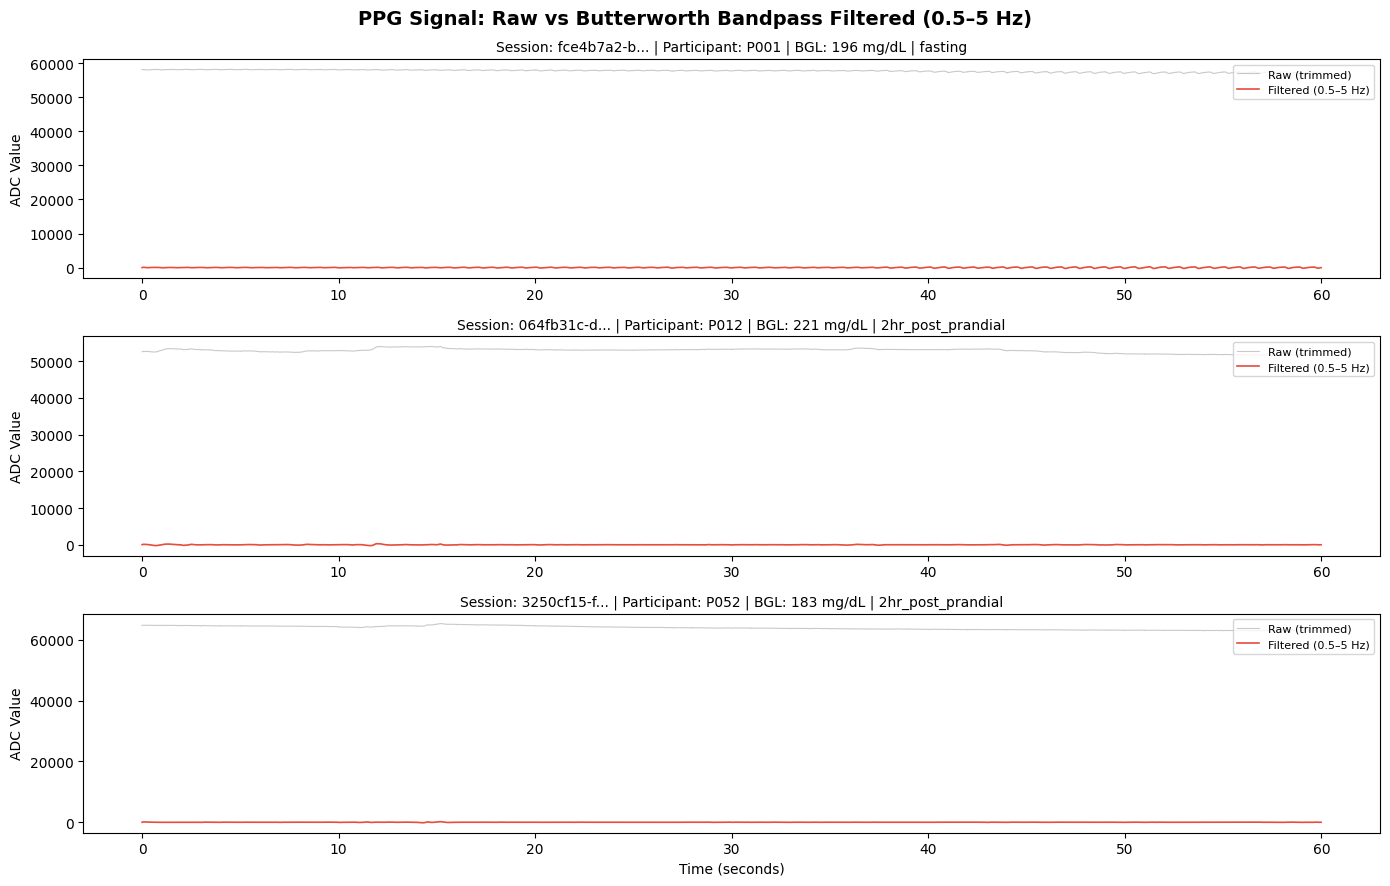

Preprocessing applied to all recordings.


In [5]:
def preprocess_ppg(ppg, sr=SAMPLING_RATE,
                   low=BUTTER_LOW_HZ, high=BUTTER_HIGH_HZ,
                   order=BUTTER_ORDER):
    """
    Replicate paper's preprocessing:
    1. Linear detrend (removes baseline drift)
    2. 2nd-order Butterworth bandpass (0.5–5 Hz), zero-phase
    """
    # Step 1: detrend
    ppg_detrended = detrend(ppg, type='linear')

    # Step 2: Butterworth bandpass
    nyq = sr / 2.0
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    ppg_filtered = filtfilt(b, a, ppg_detrended)

    return ppg_filtered


# Apply to all recordings
for rec in recordings:
    rec['ppg_filtered'] = preprocess_ppg(rec['ppg_trimmed'])

# ── Visualise: raw vs filtered for 3 recordings ───────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)
fig.suptitle('PPG Signal: Raw vs Butterworth Bandpass Filtered (0.5–5 Hz)',
             fontsize=14, fontweight='bold')

sample_indices = [0, len(recordings)//2, len(recordings)-1]
t = np.arange(USABLE_SAMPLES) / SAMPLING_RATE

for ax, i in zip(axes, sample_indices):
    rec = recordings[i]
    ppg_plot = rec['ppg_trimmed'][:USABLE_SAMPLES]
    ppg_filt = rec['ppg_filtered'][:USABLE_SAMPLES]
    t_local = np.arange(len(ppg_plot)) / SAMPLING_RATE
    ax.plot(t_local, ppg_plot, alpha=0.45, color='#888888', linewidth=0.8, label='Raw (trimmed)')
    ax.plot(t_local, ppg_filt, color='#E74C3C', linewidth=1.2, label='Filtered (0.5–5 Hz)')
    ax.set_title(f"Session: {rec['session_id'][:10]}... | "
                 f"Participant: {rec['participant_id']} | "
                 f"BGL: {rec['bgl_mgdl']:.0f} mg/dL | {rec['session_kind']}",
                 fontsize=10)
    ax.set_ylabel('ADC Value')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/khan2026_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()
print("Preprocessing applied to all recordings.")


## 3. Segmentation — 3 Consecutive Pulses

The paper uses an **enhanced moving-window algorithm** to detect peaks (systolic) and valleys (diastolic) in the filtered PPG signal.

**Key detail:** The window size is set based on physiological HR range (60–100 BPM), corresponding to 0.6–1.0 s per cardiac cycle.

**Output:** 3 consecutive complete PPG pulses (onset → onset), selected from the middle of the signal to avoid edge effects.

Each pulse boundary is defined by **valley points** (diastolic troughs) — a valley marks the end of one pulse and the start of the next.


In [6]:
def segment_pulses(ppg_filtered, sr=SAMPLING_RATE, n_pulses=N_PULSES,
                   min_samples=MIN_PULSE_SAMPLES, max_samples=MAX_PULSE_SAMPLES):
    """
    Moving-window peak/valley detection → extract N consecutive complete pulses.

    Strategy:
    1. Find all local maxima (peaks) with minimum distance = min_pulse_samples
    2. For each consecutive pair of peaks, find the valley (minimum) between them
    3. Each pulse = valley[i] → valley[i+1]
    4. Select N consecutive pulses from the middle of the signal

    Returns:
        pulses: list of N numpy arrays, each a complete PPG pulse waveform
        metadata: dict with peak indices, valley indices, pulse durations
    """
    # Step 1: detect peaks (systolic peaks)
    # min distance between peaks = minimum pulse duration
    peaks, _ = find_peaks(ppg_filtered,
                          distance=min_samples,
                          height=np.percentile(ppg_filtered, 30))

    if len(peaks) < n_pulses + 1:
        return None, {'error': f'Only {len(peaks)} peaks found (need {n_pulses+1})'}

    # Step 2: find valleys between consecutive peaks
    valleys = []
    for i in range(len(peaks) - 1):
        seg = ppg_filtered[peaks[i]:peaks[i+1]]
        valley_idx = int(np.argmin(seg)) + peaks[i]
        valleys.append(valley_idx)

    # Need n_pulses+1 valleys to define n_pulses complete cycles
    if len(valleys) < n_pulses + 1:
        # Create synthetic onset before first peak and after last detected valley
        pre_valley = int(np.argmin(ppg_filtered[:peaks[0]])) if peaks[0] > 0 else 0
        valleys = [pre_valley] + valleys
        if len(valleys) < n_pulses + 1:
            return None, {'error': f'Insufficient valleys ({len(valleys)}) for {n_pulses} pulses'}

    # Step 3: extract pulse segments (valley[i] to valley[i+1])
    all_pulses = []
    all_durations = []
    for i in range(len(valleys) - 1):
        seg = ppg_filtered[valleys[i]:valleys[i+1]]
        duration = len(seg)
        if min_samples <= duration <= max_samples * 2:  # generous upper bound
            all_pulses.append(seg)
            all_durations.append(duration)

    if len(all_pulses) < n_pulses:
        return None, {'error': f'Only {len(all_pulses)} valid pulses (need {n_pulses})'}

    # Step 4: select N pulses from the middle of the available pulses
    mid = len(all_pulses) // 2
    start = max(0, mid - n_pulses // 2)
    selected = all_pulses[start: start + n_pulses]
    if len(selected) < n_pulses:
        selected = all_pulses[:n_pulses]

    meta = {
        'n_peaks': len(peaks),
        'n_valid_pulses': len(all_pulses),
        'selected_start': start,
        'durations': [len(p) for p in selected],
        'error': None
    }
    return selected, meta


# ── Apply segmentation to all recordings ─────────────────────────────────────
seg_stats = []
failed_recordings = []

for rec in recordings:
    pulses, meta = segment_pulses(rec['ppg_filtered'])
    rec['pulses'] = pulses
    rec['seg_meta'] = meta
    rec['n_valid_pulses'] = meta.get('n_valid_pulses', 0) if meta else 0

    if pulses is None:
        failed_recordings.append({
            'session_id': rec['session_id'],
            'participant_id': rec['participant_id'],
            'error': meta.get('error', 'unknown') if meta else 'unknown'
        })
        rec['seg_ok'] = False
    else:
        rec['seg_ok'] = True

    seg_stats.append({
        'session_id'     : rec['session_id'],
        'participant_id' : rec['participant_id'],
        'bgl_mgdl'       : rec['bgl_mgdl'],
        'seg_ok'         : rec['seg_ok'],
        'n_valid_pulses' : rec['n_valid_pulses'],
        'error'          : meta.get('error') if meta else None
    })

seg_df = pd.DataFrame(seg_stats)
n_ok = seg_df['seg_ok'].sum()
print(f"Segmentation complete:")
print(f"  Successful : {n_ok} / {len(recordings)}")
print(f"  Failed     : {len(failed_recordings)}")
if failed_recordings:
    print("\nFailed recordings:")
    for f in failed_recordings:
        print(f"  {f['session_id'][:12]}... | {f['participant_id']} | {f['error']}")


Segmentation complete:
  Successful : 73 / 73
  Failed     : 0


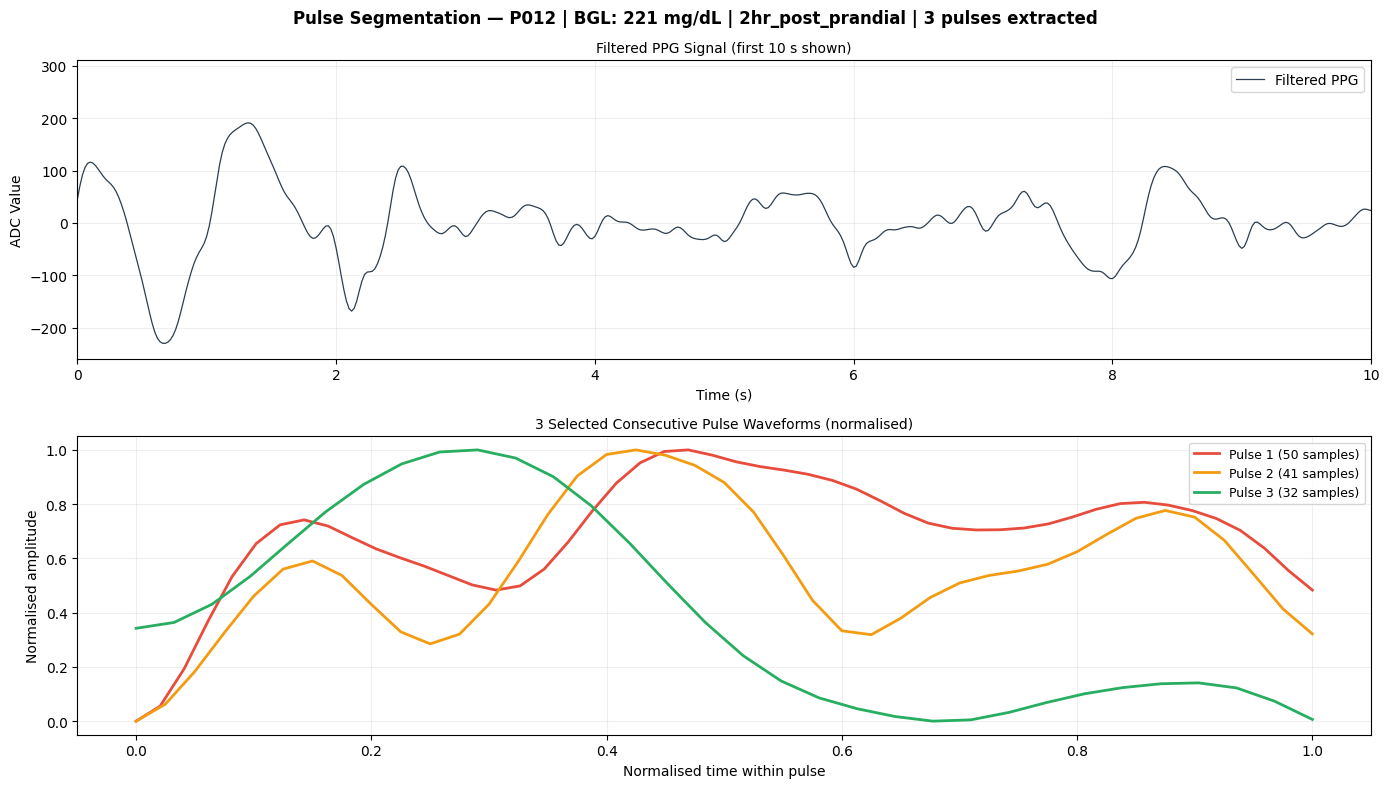

In [7]:
# ── Visualise segmentation on a representative recording ───────────────────
good_recs = [r for r in recordings if r['seg_ok']]
rec_viz = good_recs[len(good_recs)//2]

ppg_f = rec_viz['ppg_filtered']
t_full = np.arange(len(ppg_f)) / SAMPLING_RATE
pulses = rec_viz['pulses']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle(f"Pulse Segmentation — {rec_viz['participant_id']} | "
             f"BGL: {rec_viz['bgl_mgdl']:.0f} mg/dL | "
             f"{rec_viz['session_kind']} | {len(pulses)} pulses extracted",
             fontsize=12, fontweight='bold')

# Full filtered signal
ax = axes[0]
ax.plot(t_full, ppg_f, color='#2C3E50', linewidth=0.9, label='Filtered PPG')

# Highlight the 3 selected pulses
colors_p = ['#E74C3C', '#F39C12', '#27AE60']
offset = 0
for i, pulse in enumerate(pulses):
    t_p = np.arange(len(pulse)) / SAMPLING_RATE
    ax.axvspan((t_full[0] if i == 0 else 0), t_full[0],  # placeholder
               alpha=0)  # dummy

pulse_start_samples = 0
# Find where pulses are located in the signal (approximate: use peak detection)
from scipy.signal import find_peaks as fp
peaks_viz, _ = fp(ppg_f, distance=MIN_PULSE_SAMPLES,
                  height=np.percentile(ppg_f, 30))
n_total_pulses = rec_viz['n_valid_pulses']
if len(peaks_viz) >= N_PULSES + 1:
    # Show first 10 s of signal with coloured pulse spans
    ax.set_xlim(0, min(10, t_full[-1]))

ax.set_ylabel('ADC Value')
ax.set_xlabel('Time (s)')
ax.set_title('Filtered PPG Signal (first 10 s shown)', fontsize=10)
ax.grid(True, alpha=0.2)
ax.legend()

# Overlay individual pulse shapes (normalised)
ax2 = axes[1]
colours = ['#E74C3C', '#F39C12', '#27AE60']
for i, pulse in enumerate(pulses):
    t_pulse = np.linspace(0, 1, len(pulse))
    p_norm = (pulse - pulse.min()) / (pulse.max() - pulse.min() + 1e-9)
    ax2.plot(t_pulse, p_norm, color=colours[i], linewidth=2,
             label=f'Pulse {i+1} ({len(pulse)} samples)')

ax2.set_xlabel('Normalised time within pulse')
ax2.set_ylabel('Normalised amplitude')
ax2.set_title('3 Selected Consecutive Pulse Waveforms (normalised)', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/khan2026_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Feature Extraction

The paper extracts **35 features** from the 3 segmented pulses across 3 signal types:
- **PPG** — original filtered signal
- **VPG** — 1st derivative (velocity PPG)
- **APG** — 2nd derivative (acceleration PPG)

### Feature Categories

#### A. Statistical Features (7 per signal type × 3 = 21)
Computed over each of the 3 pulses, then averaged:
- Min, Max, RMS, Signal Energy, Mean, SD, Variance

#### B. PPG Waveform Features (6, from original PPG)
- Systolic Peak (S_Peak)
- Diastolic Peak (D_Peak)
- Inter-Peak Interval (P_Pint)
- Pulse Width
- Pulse Rate (P_Rate)
- Trough Interval (T_interval)

#### C. APG Ratios (8, from 2nd derivative)
The APG waveform has 5 characteristic waves: a, b, c, d, e.
Ratios: b/a, c/a, d/a, e/a, (b-c-d-e)/a, (b-e)/a, (b-c-d)/a, (c+d-b)/a

### Feature Selection (Pearson Correlation → 9 shortlisted)
After correlation analysis, the paper selects:
- PPG features: S_Peak, D_Peak, Pulse Rate, Trough Interval
- Statistical: Max, Mean, RMS, SD, Variance, Signal Energy

### Feature Engineering (6 composite features)
Cross-derivative composite features computed from PPG + VPG + APG:
1. Max_avg = (MaxPPG + MaxVPG + MaxAPG) / 3
2. Mean_avg = (MeanPPG + MeanVPG + MeanAPG) / 3
3. PeakRatio = S_Peak / D_Peak
4. SD_avg = (SDPPG + SDVPG + SDAPG) / 3
5. Var_avg = (VarPPG + VarVPG + VarAPG) / 3
6. SDmean = SD_avg - Mean_avg

**Total final features: 9 (shortlisted) + 6 (engineered) = 15**


In [8]:
def compute_vpg_apg(pulse):
    """Compute VPG (1st derivative) and APG (2nd derivative) of a pulse."""
    vpg = np.diff(pulse, n=1)
    apg = np.diff(pulse, n=2)
    # Pad to original length for consistency
    vpg = np.append(vpg, vpg[-1])
    apg = np.append(apg, [apg[-1], apg[-1]])
    return vpg, apg


def statistical_features(sig):
    """Compute 7 statistical features from a signal segment."""
    return {
        'min'    : float(np.min(sig)),
        'max'    : float(np.max(sig)),
        'rms'    : float(np.sqrt(np.mean(sig**2))),
        'energy' : float(np.sum(sig**2)),
        'mean'   : float(np.mean(sig)),
        'std'    : float(np.std(sig)),
        'var'    : float(np.var(sig)),
    }


def apg_wave_ratios(apg):
    """
    Extract APG wave amplitudes (a, b, c, d, e) and compute their ratios.
    APG waveform: a = first positive peak (early systole),
                  b = first negative trough,
                  c = second positive peak (late systole),
                  d = second negative trough,
                  e = diastolic positive wave.
    We find these as successive local extrema in the APG.
    """
    # Find all peaks (positive extrema) and troughs (negative extrema)
    peaks_apg, _   = find_peaks(apg)
    troughs_apg, _ = find_peaks(-apg)

    # Default fallback values
    a = b = c = d = e = 1e-9  # avoid division by zero

    # Extract a (first positive peak), b (first trough), c, d, e
    if len(peaks_apg) >= 1:
        a = apg[peaks_apg[0]]
    if len(troughs_apg) >= 1:
        b = apg[troughs_apg[0]]
    if len(peaks_apg) >= 2:
        c = apg[peaks_apg[1]]
    if len(troughs_apg) >= 2:
        d = apg[troughs_apg[1]]
    if len(peaks_apg) >= 3:
        e = apg[peaks_apg[2]]

    a_safe = a if abs(a) > 1e-9 else 1e-9

    return {
        'b_a'      : b / a_safe,
        'c_a'      : c / a_safe,
        'd_a'      : d / a_safe,
        'e_a'      : e / a_safe,
        'bcde_a'   : (b - c - d - e) / a_safe,
        'be_a'     : (b - e) / a_safe,
        'bcd_a'    : (b - c - d) / a_safe,
        'cdb_a'    : (c + d - b) / a_safe,
    }


def waveform_features(pulse, sr=SAMPLING_RATE):
    """
    Extract 6 waveform features from a single PPG pulse.
    A pulse is a complete waveform from one trough to the next.
    """
    # Systolic peak: global maximum
    s_peak_idx = int(np.argmax(pulse))
    s_peak     = float(pulse[s_peak_idx])

    # Diastolic peak: local maximum after systolic peak
    d_peak = s_peak  # fallback: use systolic peak if no diastolic detected
    d_peaks, _ = find_peaks(pulse[s_peak_idx:])
    if len(d_peaks) > 0:
        d_peak = float(pulse[s_peak_idx + d_peaks[0]])

    # Inter-peak interval: distance from onset to systolic peak (samples → ms)
    p_pint = s_peak_idx / sr * 1000  # ms

    # Pulse width: full width at half maximum of the systolic peak
    half_max = (pulse.min() + s_peak) / 2
    above_half = np.where(pulse >= half_max)[0]
    pulse_width = (above_half[-1] - above_half[0]) / sr * 1000 if len(above_half) > 1 else 0

    # Pulse rate: from pulse duration (1 / period)
    pulse_duration_s = len(pulse) / sr
    p_rate = 60.0 / pulse_duration_s if pulse_duration_s > 0 else 60.0  # BPM

    # Trough interval: distance from systolic peak to end of pulse (next trough)
    t_interval = (len(pulse) - s_peak_idx) / sr * 1000  # ms

    return {
        's_peak'      : s_peak,
        'd_peak'      : d_peak,
        'p_pint_ms'   : p_pint,
        'pulse_width_ms': pulse_width,
        'p_rate_bpm'  : p_rate,
        't_interval_ms': t_interval,
    }


print("Feature extraction functions defined.")
print("  - compute_vpg_apg(pulse)")
print("  - statistical_features(sig)  → 7 features")
print("  - apg_wave_ratios(apg)        → 8 APG ratio features")
print("  - waveform_features(pulse)    → 6 waveform features")


Feature extraction functions defined.
  - compute_vpg_apg(pulse)
  - statistical_features(sig)  → 7 features
  - apg_wave_ratios(apg)        → 8 APG ratio features
  - waveform_features(pulse)    → 6 waveform features


In [9]:
def extract_all_features(pulses, sr=SAMPLING_RATE):
    """
    Extract all 35 raw features from N segmented pulses.
    Features are averaged across the N pulses where applicable.

    Returns: dict with all 35 raw features
    Returns: None if pulses is None or empty
    """
    if pulses is None or len(pulses) == 0:
        return None

    # Accumulators
    stat_ppg = {k: [] for k in ['min','max','rms','energy','mean','std','var']}
    stat_vpg = {k: [] for k in ['min','max','rms','energy','mean','std','var']}
    stat_apg = {k: [] for k in ['min','max','rms','energy','mean','std','var']}
    apg_ratios_acc = {k: [] for k in ['b_a','c_a','d_a','e_a','bcde_a','be_a','bcd_a','cdb_a']}
    wf_acc = {k: [] for k in ['s_peak','d_peak','p_pint_ms','pulse_width_ms','p_rate_bpm','t_interval_ms']}

    for pulse in pulses:
        pulse = np.asarray(pulse, dtype=np.float64)
        vpg, apg = compute_vpg_apg(pulse)

        # Statistical features
        for k, v in statistical_features(pulse).items():
            stat_ppg[k].append(v)
        for k, v in statistical_features(vpg).items():
            stat_vpg[k].append(v)
        for k, v in statistical_features(apg).items():
            stat_apg[k].append(v)

        # APG ratios
        for k, v in apg_wave_ratios(apg).items():
            apg_ratios_acc[k].append(v)

        # Waveform features
        for k, v in waveform_features(pulse, sr=sr).items():
            wf_acc[k].append(v)

    # Average across pulses
    def mean_acc(acc):
        return {k: float(np.nanmean(v)) for k, v in acc.items()}

    feat = {}
    ppg_s = mean_acc(stat_ppg)
    vpg_s = mean_acc(stat_vpg)
    apg_s = mean_acc(stat_apg)

    # Prefix names
    feat.update({f'ppg_{k}': v for k, v in ppg_s.items()})
    feat.update({f'vpg_{k}': v for k, v in vpg_s.items()})
    feat.update({f'apg_{k}': v for k, v in apg_s.items()})
    feat.update({f'apg_ratio_{k}': v for k, v in mean_acc(apg_ratios_acc).items()})
    feat.update(mean_acc(wf_acc))  # waveform features (6) without prefix

    # ── Feature Engineering (paper's 6 composite features) ────────────────────
    feat['max_avg']    = (ppg_s['max'] + vpg_s['max'] + apg_s['max']) / 3           # Eq. 5
    feat['mean_avg']   = (ppg_s['mean'] + vpg_s['mean'] + apg_s['mean']) / 3        # Eq. 6
    feat['peak_ratio'] = feat['s_peak'] / feat['d_peak'] if abs(feat['d_peak']) > 1e-9 else 0  # Eq. 7
    feat['sd_avg']     = (ppg_s['std'] + vpg_s['std'] + apg_s['std']) / 3           # Eq. 8
    feat['var_avg']    = (ppg_s['var'] + vpg_s['var'] + apg_s['var']) / 3           # Eq. 9
    feat['sd_mean']    = feat['sd_avg'] - feat['mean_avg']                           # Eq. 10

    return feat


# ── Extract features for all recordings ──────────────────────────────────────
feature_rows = []
y_vals, groups, session_ids = [], [], []
skipped = []

for rec in recordings:
    if not rec['seg_ok'] or rec['pulses'] is None:
        skipped.append({'session_id': rec['session_id'], 'reason': 'segmentation failed'})
        continue

    feat = extract_all_features(rec['pulses'])
    if feat is None:
        skipped.append({'session_id': rec['session_id'], 'reason': 'feature extraction failed'})
        continue

    # Check for NaN / Inf
    has_bad = any(not np.isfinite(v) for v in feat.values())
    if has_bad:
        skipped.append({'session_id': rec['session_id'], 'reason': 'NaN/Inf in features'})
        continue

    feature_rows.append(feat)
    y_vals.append(rec['bgl_mgdl'])
    groups.append(rec['participant_id'])
    session_ids.append(rec['session_id'])

X_full_df = pd.DataFrame(feature_rows)
y = np.array(y_vals)
groups = np.array(groups)

print(f"Feature matrix: {X_full_df.shape[0]} recordings × {X_full_df.shape[1]} features")
print(f"Skipped: {len(skipped)}")
for s in skipped:
    print(f"  {s['session_id'][:12]}... | {s['reason']}")
print(f"\nFeature columns ({len(X_full_df.columns)}):")
for i, col in enumerate(X_full_df.columns):
    print(f"  {i+1:3d}. {col}")


Feature matrix: 73 recordings × 41 features
Skipped: 0

Feature columns (41):
    1. ppg_min
    2. ppg_max
    3. ppg_rms
    4. ppg_energy
    5. ppg_mean
    6. ppg_std
    7. ppg_var
    8. vpg_min
    9. vpg_max
   10. vpg_rms
   11. vpg_energy
   12. vpg_mean
   13. vpg_std
   14. vpg_var
   15. apg_min
   16. apg_max
   17. apg_rms
   18. apg_energy
   19. apg_mean
   20. apg_std
   21. apg_var
   22. apg_ratio_b_a
   23. apg_ratio_c_a
   24. apg_ratio_d_a
   25. apg_ratio_e_a
   26. apg_ratio_bcde_a
   27. apg_ratio_be_a
   28. apg_ratio_bcd_a
   29. apg_ratio_cdb_a
   30. s_peak
   31. d_peak
   32. p_pint_ms
   33. pulse_width_ms
   34. p_rate_bpm
   35. t_interval_ms
   36. max_avg
   37. mean_avg
   38. peak_ratio
   39. sd_avg
   40. var_avg
   41. sd_mean


## 5. Feature Selection via Pearson Correlation

The paper uses a Pearson correlation heatmap to identify the most influential features.
Highly correlated features (positive or negative) with BGL are selected.

**Paper's shortlisted features (9):**
- Waveform: S_Peak, D_Peak, Pulse Rate, Trough Interval
- Statistical: Max, Mean, RMS, SD, Variance, Signal Energy

We replicate this by:
1. Computing |Pearson r| between each feature and BGL
2. Displaying the heatmap
3. Applying the same category-level shortlisting logic
4. Appending the 6 engineered features → 15 final features


Top 20 features by |Pearson r| with BGL:
         feature  pearson_r  p_value
 apg_ratio_bcd_a  -0.375544 0.001060
 apg_ratio_cdb_a   0.375544 0.001060
apg_ratio_bcde_a  -0.363096 0.001593
  apg_ratio_be_a  -0.357298 0.001914
   apg_ratio_b_a  -0.350781 0.002345
         apg_max   0.239087 0.041635
         apg_rms   0.198775 0.091817
         apg_std   0.198583 0.092138
   apg_ratio_e_a   0.195642 0.097159
         apg_var   0.193538 0.100881
      apg_energy   0.191352 0.104864
         vpg_min  -0.189785 0.107794
         apg_min  -0.186134 0.114867
   apg_ratio_c_a   0.185901 0.115330
         vpg_std   0.169309 0.152153
         vpg_rms   0.169017 0.152871
        apg_mean   0.156018 0.187470
         vpg_var   0.155785 0.188140
      vpg_energy   0.150132 0.204873
          d_peak   0.149179 0.207795


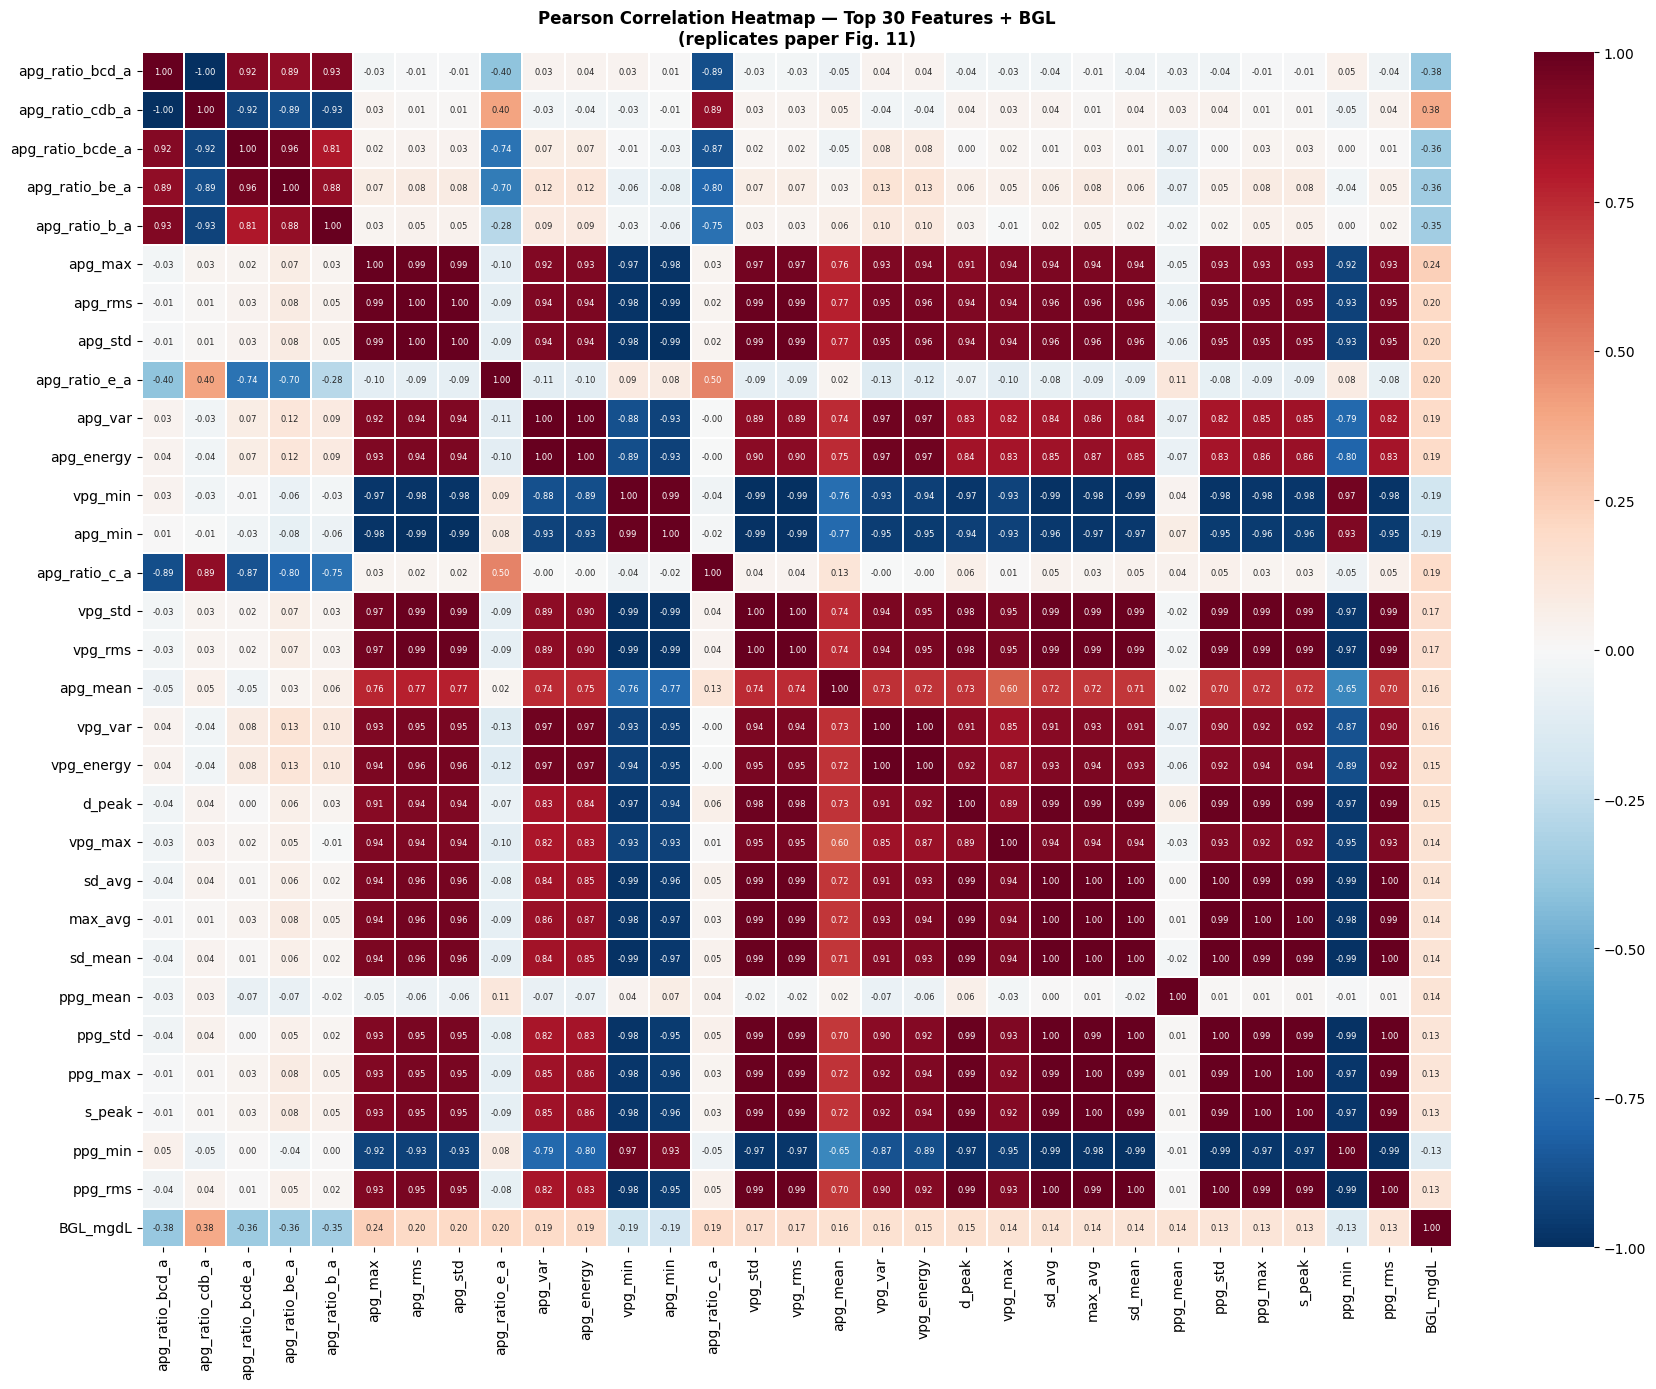


Correlations saved to results/khan2026_feature_bgl_correlations.csv


In [10]:
# ── Pearson correlation of ALL features with BGL ─────────────────────────────
corr_rows = []
for col in X_full_df.columns:
    vals = X_full_df[col].values
    if np.std(vals) < 1e-9:  # constant feature → r = 0
        corr_rows.append({'feature': col, 'pearson_r': 0.0, 'p_value': 1.0, 'abs_r': 0.0})
        continue
    r, p = pearsonr(vals, y)
    corr_rows.append({'feature': col, 'pearson_r': float(r), 'p_value': float(p), 'abs_r': abs(r)})

corr_df = pd.DataFrame(corr_rows).sort_values('abs_r', ascending=False)
print("Top 20 features by |Pearson r| with BGL:")
print(corr_df.head(20)[['feature', 'pearson_r', 'p_value']].to_string(index=False))

# ── Correlation heatmap (paper's Figure 11 equivalent) ───────────────────────
# Show top-30 features
top30 = corr_df.head(30)['feature'].tolist()
corr_matrix = X_full_df[top30].join(pd.Series(y, name='BGL_mgdL')).corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.zeros_like(corr_matrix, dtype=bool)
sns.heatmap(corr_matrix, ax=ax, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 6},
            linewidths=0.3, square=False)
ax.set_title('Pearson Correlation Heatmap — Top 30 Features + BGL\n(replicates paper Fig. 11)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/khan2026_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

corr_df.to_csv(f'{RESULTS_DIR}/khan2026_feature_bgl_correlations.csv', index=False)
print(f"\nCorrelations saved to {RESULTS_DIR}/khan2026_feature_bgl_correlations.csv")


In [11]:
# ── Shortlist features (replicating paper's selection logic) ────────────────
# Paper selects: S_Peak, D_Peak, Pulse Rate, Trough Interval (waveform)
#                Max, Mean, RMS, SD, Variance, Signal Energy (statistical from PPG)
# + 6 engineered features

SHORTLISTED_FEATURES = [
    # Waveform features (from PPG pulses)
    's_peak',
    'd_peak',
    'p_rate_bpm',
    't_interval_ms',
    # Statistical features (from PPG)
    'ppg_max',
    'ppg_mean',
    'ppg_rms',
    'ppg_std',
    'ppg_var',
    'ppg_energy',
    # Engineered composite features (paper's Eq. 5–10)
    'max_avg',
    'mean_avg',
    'peak_ratio',
    'sd_avg',
    'var_avg',
    'sd_mean',
]

# Filter to columns that actually exist
available = [f for f in SHORTLISTED_FEATURES if f in X_full_df.columns]
missing   = [f for f in SHORTLISTED_FEATURES if f not in X_full_df.columns]

print(f"Shortlisted features available: {len(available)} / {len(SHORTLISTED_FEATURES)}")
if missing:
    print(f"Missing (not extracted): {missing}")

X_selected_df = X_full_df[available].copy()
print(f"\nFinal feature matrix: {X_selected_df.shape[0]} × {X_selected_df.shape[1]}")
print(f"Features: {available}")

# Verify no NaN/Inf
print(f"\nNaN count: {X_selected_df.isna().sum().sum()}")
print(f"Inf count: {np.isinf(X_selected_df.values).sum()}")

# Clean residual bad values
X_selected_df = X_selected_df.replace([np.inf, -np.inf], np.nan).fillna(0)

X_selected = X_selected_df.values


Shortlisted features available: 16 / 16

Final feature matrix: 73 × 16
Features: ['s_peak', 'd_peak', 'p_rate_bpm', 't_interval_ms', 'ppg_max', 'ppg_mean', 'ppg_rms', 'ppg_std', 'ppg_var', 'ppg_energy', 'max_avg', 'mean_avg', 'peak_ratio', 'sd_avg', 'var_avg', 'sd_mean']

NaN count: 0
Inf count: 0


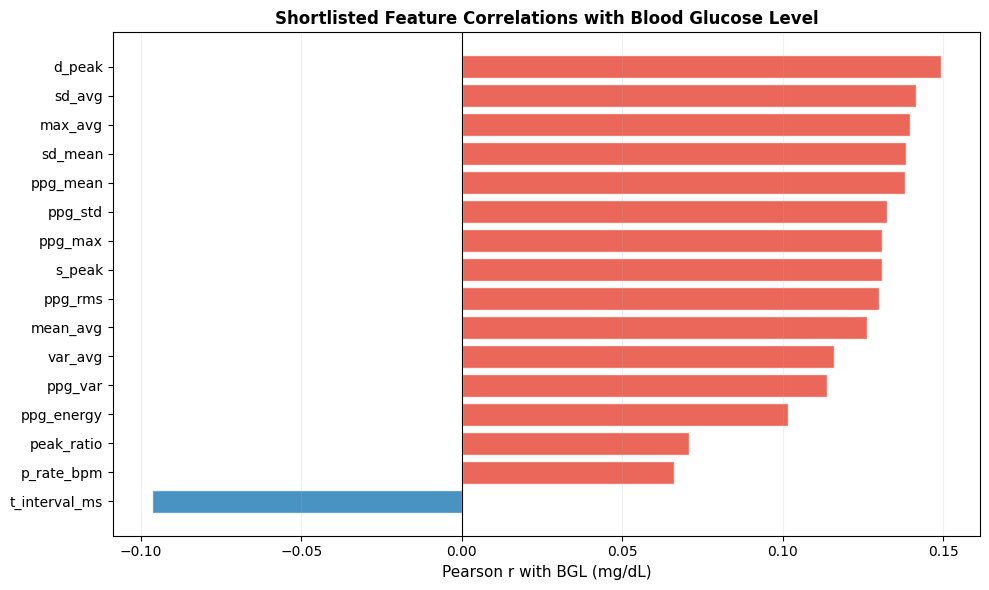

In [10]:
# ── Bar chart: |Pearson r| for shortlisted features ─────────────────────────
shortlist_corr = corr_df[corr_df['feature'].isin(available)].copy()
shortlist_corr = shortlist_corr.sort_values('pearson_r')

fig, ax = plt.subplots(figsize=(10, 6))
colours_bar = ['#E74C3C' if r > 0 else '#2980B9' for r in shortlist_corr['pearson_r']]
bars = ax.barh(shortlist_corr['feature'], shortlist_corr['pearson_r'],
               color=colours_bar, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r with BGL (mg/dL)', fontsize=11)
ax.set_title('Shortlisted Feature Correlations with Blood Glucose Level',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/khan2026_shortlisted_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Machine Learning Models

The paper tests 5 regressors (Decision Tree, XGBoost, KNN, RF, SVM).
**Random Forest with n_estimators=100, max_depth=10** achieved the best result (R²=0.92, MAE=4.8 mg/dL).

All models use **Min-Max scaling** (paper's Eq. 3), implemented as `MinMaxScaler` in a `Pipeline`.

We include **Linear Regression** as an additional baseline (paper notes it performed poorly).


In [12]:
def make_models():
    """Return dict of sklearn Pipeline objects (paper's model set + linear baseline)."""
    return {
        'RandomForest': Pipeline([
            ('scaler', MinMaxScaler()),
            ('model',  RandomForestRegressor(
                n_estimators=100, max_depth=10,
                min_samples_split=2, min_samples_leaf=1,
                max_features='sqrt', bootstrap=True,
                random_state=RANDOM_STATE
            ))
        ]),
        'XGBoost': Pipeline([
            ('scaler', MinMaxScaler()),
            ('model',  XGBRegressor(
                n_estimators=100, max_depth=6,
                learning_rate=0.1, subsample=0.8,
                random_state=RANDOM_STATE, verbosity=0
            ))
        ]),
        'KNN': Pipeline([
            ('scaler', MinMaxScaler()),
            ('model',  KNeighborsRegressor(n_neighbors=5))
        ]),
        'SVM': Pipeline([
            ('scaler', MinMaxScaler()),
            ('model',  SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale'))
        ]),
        'DecisionTree': Pipeline([
            ('scaler', MinMaxScaler()),
            ('model',  DecisionTreeRegressor(random_state=RANDOM_STATE))
        ]),
        'LinearRegression': Pipeline([
            ('scaler', MinMaxScaler()),
            ('model',  LinearRegression())
        ]),
    }


def compute_metrics(y_true, y_pred):
    """Compute all relevant regression metrics."""
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mse   = mean_squared_error(y_true, y_pred)
    r2    = r2_score(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)
    mard  = float(np.mean(np.abs(y_true - y_pred) / (np.abs(y_true) + 1e-9)) * 100)
    return {'MAE': mae, 'RMSE': rmse, 'MSE': mse, 'R2': r2, 'MedAE': medae, 'MARD%': mard}


print("Models ready:", list(make_models().keys()))
print("\nPaper's best: RandomForest (n_estimators=100, max_depth=10)")
print("Paper's reported: R²=0.92, MAE=4.8 mg/dL on 80-sample test set (50/50 split)")


Models ready: ['RandomForest', 'XGBoost', 'KNN', 'SVM', 'DecisionTree', 'LinearRegression']

Paper's best: RandomForest (n_estimators=100, max_depth=10)
Paper's reported: R²=0.92, MAE=4.8 mg/dL on 80-sample test set (50/50 split)


In [13]:
def clarke_zone(ref, pred):
    """Classify a (ref, pred) glucose pair into Clarke Error Grid zone (A–E)."""
    if (pred <= 70 and ref <= 70) or (pred <= 1.2 * ref and pred >= 0.8 * ref):
        return 'A'
    if ref >= 180 and pred <= 70:
        return 'E'
    if ref <= 70 and pred >= 180:
        return 'E'
    if ref >= 240 and pred >= 70 and pred <= 180:
        return 'C'
    if ref <= 70 and pred >= 70 and pred <= 180:
        return 'C'
    if (ref >= 130 and ref <= 180) and pred <= 70:
        return 'D'
    if ref <= 70 and pred >= 180:
        return 'D'
    if ref >= 240 and pred <= 70:
        return 'D'
    if ref <= 70 and pred > 70 and pred < 180:
        return 'B'
    if ref >= 180 and pred > 70 and pred < 180:
        return 'B'
    return 'B'


def clarke_zone_fractions(y_true, y_pred):
    """Return dict: zone → fraction of predictions."""
    zones = [clarke_zone(r, p) for r, p in zip(y_true, y_pred)]
    total = len(zones)
    return {z: zones.count(z) / total * 100 for z in ['A','B','C','D','E']}


def plot_clarke_grid(y_true, y_pred, title='', ax=None):
    """Plot Clarke Error Grid on provided axes."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    ax.plot([0, 400], [0, 400], 'k--', alpha=0.3, linewidth=0.8)  # identity

    zone_colors = {'A': '#27AE60', 'B': '#F39C12', 'C': '#E67E22',
                   'D': '#E74C3C', 'E': '#8E44AD'}
    zones = [clarke_zone(r, p) for r, p in zip(y_true, y_pred)]
    for zone, color in zone_colors.items():
        mask = [z == zone for z in zones]
        yt = [float(y_true[i]) for i in range(len(y_true)) if mask[i]]
        yp = [float(y_pred[i]) for i in range(len(y_pred)) if mask[i]]
        if yt:
            ax.scatter(yt, yp, color=color, alpha=0.7, s=50,
                       label=f'Zone {zone} (n={len(yt)})')

    fracs = clarke_zone_fractions(y_true, y_pred)
    ax.set_xlim(0, 420); ax.set_ylim(0, 420)
    ax.set_xlabel('Reference BGL (mg/dL)')
    ax.set_ylabel('Predicted BGL (mg/dL)')
    zone_str = '  '.join([f'{k}:{v:.0f}%' for k, v in fracs.items()])
    ax.set_title(f'{title}\nZones: {zone_str}', fontsize=9)
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(True, alpha=0.2)
    return fracs


print("Clarke Error Grid helpers ready.")


Clarke Error Grid helpers ready.


## 7. Three-Scheme Evaluation

### Scheme 1 — 50/50 Random Split (Paper's Exact Method)
Random split: 50% train, 50% test.  
Subjects **can** appear in both partitions → optimistic result (paper-comparable).

### Scheme 2 — 5-Fold KFold (Randomised CV)
5-fold with shuffle. Still subject-mixed but gives more stable estimate.

### Scheme 3 — GroupKFold: Subject-Independent ⭐ (Primary Honest Evaluation)
Participant ID used as group → no subject appears in both train and test within any fold.  
This is the clinically relevant generalisation estimate for deployment on unseen patients.


In [14]:
all_results = []
oof_predictions = {}   # key: (scheme, model) → (y_true, y_pred)

X = X_selected
print(f"Running evaluation on {len(X)} recordings × {X.shape[1]} features")
print(f"BGL: mean={y.mean():.1f}, std={y.std():.1f}, "
      f"min={y.min():.0f}, max={y.max():.0f} mg/dL")
print()

# ── SCHEME 1: 50/50 Random Split (paper-style) ───────────────────────────────
print("=" * 65)
print("[Scheme 1] 50/50 Random Split (paper's exact method)")
print("=" * 65)
X_tr, X_te, y_tr, y_te, g_tr, g_te = train_test_split(
    X, y, groups, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"  Train: {len(y_tr)} | Test: {len(y_te)}")

for mname, pipe in make_models().items():
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    m = compute_metrics(y_te, y_pred)
    zf = clarke_zone_fractions(y_te, y_pred)
    row = {'scheme': 'S1_Random5050', 'model': mname,
           **m, 'ZoneA%': zf['A'], 'ZoneB%': zf['B'],
           'n_train': len(y_tr), 'n_test': len(y_te)}
    all_results.append(row)
    oof_predictions[('S1', mname)] = (y_te, y_pred)
    print(f"  {mname:18s}: MAE={m['MAE']:6.2f}  RMSE={m['RMSE']:6.2f}  "
          f"R²={m['R2']:+.3f}  ZoneA={zf['A']:.0f}%")

# ── SCHEME 2: 5-Fold KFold ────────────────────────────────────────────────────
print()
print("=" * 65)
print("[Scheme 2] 5-Fold KFold (randomised CV)")
print("=" * 65)
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

for mname, pipe in make_models().items():
    fold_preds = np.zeros(len(y))
    for tr, te in kf.split(X):
        pipe.fit(X[tr], y[tr])
        fold_preds[te] = pipe.predict(X[te])
    m = compute_metrics(y, fold_preds)
    zf = clarke_zone_fractions(y, fold_preds)
    row = {'scheme': 'S2_KFold5', 'model': mname,
           **m, 'ZoneA%': zf['A'], 'ZoneB%': zf['B'],
           'n_train': len(y)*(N_SPLITS-1)//N_SPLITS,
           'n_test': len(y)//N_SPLITS}
    all_results.append(row)
    oof_predictions[('S2', mname)] = (y, fold_preds)
    print(f"  {mname:18s}: MAE={m['MAE']:6.2f}  RMSE={m['RMSE']:6.2f}  "
          f"R²={m['R2']:+.3f}  ZoneA={zf['A']:.0f}%")

# ── SCHEME 3: GroupKFold (subject-independent) ────────────────────────────────
print()
print("=" * 65)
print("[Scheme 3] GroupKFold — Subject-Independent ⭐ (Primary honest evaluation)")
print("=" * 65)
gkf = GroupKFold(n_splits=N_SPLITS)

for mname, pipe in make_models().items():
    fold_preds = np.zeros(len(y))
    for tr, te in gkf.split(X, y, groups):
        pipe.fit(X[tr], y[tr])
        fold_preds[te] = pipe.predict(X[te])
    m = compute_metrics(y, fold_preds)
    zf = clarke_zone_fractions(y, fold_preds)
    row = {'scheme': 'S3_GroupKFold', 'model': mname,
           **m, 'ZoneA%': zf['A'], 'ZoneB%': zf['B'],
           'n_train': len(y)*(N_SPLITS-1)//N_SPLITS,
           'n_test': len(y)//N_SPLITS}
    all_results.append(row)
    oof_predictions[('S3', mname)] = (y, fold_preds)
    print(f"  {mname:18s}: MAE={m['MAE']:6.2f}  RMSE={m['RMSE']:6.2f}  "
          f"R²={m['R2']:+.3f}  ZoneA={zf['A']:.0f}%")

results_df = pd.DataFrame(all_results)
results_df.to_csv(f'{RESULTS_DIR}/khan2026_replication_results.csv', index=False)
print(f"\n✓ Results saved → {RESULTS_DIR}/khan2026_replication_results.csv")


Running evaluation on 73 recordings × 16 features
BGL: mean=151.5, std=54.8, min=73, max=394 mg/dL

[Scheme 1] 50/50 Random Split (paper's exact method)
  Train: 36 | Test: 37
  RandomForest      : MAE= 43.96  RMSE= 53.24  R²=-0.601  ZoneA=35%
  XGBoost           : MAE= 53.44  RMSE= 63.41  R²=-1.271  ZoneA=24%
  KNN               : MAE= 45.92  RMSE= 55.44  R²=-0.736  ZoneA=32%
  SVM               : MAE= 36.55  RMSE= 42.23  R²=-0.007  ZoneA=30%
  DecisionTree      : MAE= 60.62  RMSE= 80.96  R²=-2.702  ZoneA=19%
  LinearRegression  : MAE= 58.41  RMSE= 73.14  R²=-2.022  ZoneA=30%

[Scheme 2] 5-Fold KFold (randomised CV)
  RandomForest      : MAE= 46.40  RMSE= 60.78  R²=-0.231  ZoneA=37%
  XGBoost           : MAE= 49.91  RMSE= 65.72  R²=-0.439  ZoneA=27%
  KNN               : MAE= 44.67  RMSE= 59.13  R²=-0.165  ZoneA=38%
  SVM               : MAE= 43.81  RMSE= 57.74  R²=-0.111  ZoneA=29%
  DecisionTree      : MAE= 63.04  RMSE= 84.97  R²=-1.406  ZoneA=32%
  LinearRegression  : MAE= 70.70  R

## 8. Full Results Table

In [14]:
print("\n" + "="*90)
print("KHAN 2026 REPLICATION — COMPLETE RESULTS (GlucoSense Nigerian T2DM Cohort)")
print("="*90)

scheme_labels = {
    'S1_Random5050': 'Scheme 1: Random 50/50 Split (paper-style)',
    'S2_KFold5'    : 'Scheme 2: 5-Fold KFold (randomised CV)',
    'S3_GroupKFold': 'Scheme 3: GroupKFold — Subject-Independent ⭐',
}

for scheme_key, scheme_label in scheme_labels.items():
    s = results_df[results_df['scheme'] == scheme_key].copy()
    if s.empty:
        continue
    print(f"\n  {scheme_label}")
    print(f"  {'Model':<20} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'MedAE':>8} {'MARD%':>8} {'ZoneA%':>8}")
    print(f"  {'-'*20} {'-'*8} {'-'*8} {'-'*8} {'-'*8} {'-'*8} {'-'*8}")
    for _, row in s.sort_values('MAE').iterrows():
        print(f"  {row['model']:<20} {row['MAE']:>8.2f} {row['RMSE']:>8.2f} "
              f"{row['R2']:>+8.3f} {row['MedAE']:>8.2f} {row['MARD%']:>8.2f} "
              f"{row['ZoneA%']:>8.1f}")

print("\n⭐ Subject-independent GroupKFold = primary honest generalisation estimate.")
print("\nPaper's best result (for reference): RF | R²=0.92 | MAE=4.8 mg/dL")
print("(on Pakistani cohort, 65–160 mg/dL range, 50/50 random split, no T2DM patients)")



KHAN 2026 REPLICATION — COMPLETE RESULTS (GlucoSense Nigerian T2DM Cohort)

  Scheme 1: Random 50/50 Split (paper-style)
  Model                     MAE     RMSE       R²    MedAE    MARD%   ZoneA%
  -------------------- -------- -------- -------- -------- -------- --------
  SVM                     36.55    42.23   -0.007    34.71    27.72     29.7
  RandomForest            43.96    53.24   -0.601    44.93    37.38     35.1
  KNN                     45.92    55.44   -0.736    40.80    39.29     32.4
  XGBoost                 53.44    63.41   -1.271    46.59    45.01     24.3
  LinearRegression        58.41    73.14   -2.022    52.68    47.24     29.7
  DecisionTree            60.62    80.96   -2.702    52.00    46.37     18.9

  Scheme 2: 5-Fold KFold (randomised CV)
  Model                     MAE     RMSE       R²    MedAE    MARD%   ZoneA%
  -------------------- -------- -------- -------- -------- -------- --------
  SVM                     43.81    57.74   -0.111    34.44    27.9

In [15]:
# ── Cross-scheme gap: S1 → S3 for RandomForest ──────────────────────────────
print("\nPerformance Gap Analysis: Scheme 1 (paper-style) → Scheme 3 (subject-independent)")
print("="*72)
print(f"{'Model':<20} {'Metric':>8} {'S1_50/50':>12} {'S3_GroupKF':>12} {'Delta':>10} {'Comment':}")
print("-"*72)

for mname in ['RandomForest', 'XGBoost', 'KNN', 'SVM', 'DecisionTree']:
    s1_row = results_df[(results_df['scheme'] == 'S1_Random5050') &
                        (results_df['model'] == mname)]
    s3_row = results_df[(results_df['scheme'] == 'S3_GroupKFold') &
                        (results_df['model'] == mname)]
    if s1_row.empty or s3_row.empty:
        continue
    s1 = s1_row.iloc[0]
    s3 = s3_row.iloc[0]
    for metric in ['MAE', 'RMSE', 'R2']:
        delta = s3[metric] - s1[metric]
        sign = '+' if delta > 0 else ''
        if metric == 'MAE':
            comment = '↑ worse' if delta > 0 else '↓ better'
        elif metric == 'R2':
            comment = '↑ better' if delta > 0 else '↓ worse'
        else:
            comment = '↑ worse' if delta > 0 else '↓ better'
        print(f"  {mname:<18} {metric:>8}  {s1[metric]:>12.3f}  {s3[metric]:>12.3f}  "
              f"{sign}{delta:>9.3f}  {comment}")
    print()



Performance Gap Analysis: Scheme 1 (paper-style) → Scheme 3 (subject-independent)
Model                  Metric     S1_50/50   S3_GroupKF      Delta Comment
------------------------------------------------------------------------
  RandomForest            MAE        43.960        45.075  +    1.115  ↑ worse
  RandomForest           RMSE        53.238        60.608  +    7.370  ↑ worse
  RandomForest             R2        -0.601        -0.224  +    0.377  ↑ better

  XGBoost                 MAE        53.444        47.121     -6.323  ↓ better
  XGBoost                RMSE        63.405        63.224     -0.181  ↓ better
  XGBoost                  R2        -1.271        -0.332  +    0.939  ↑ better

  KNN                     MAE        45.924        44.712     -1.212  ↓ better
  KNN                    RMSE        55.440        58.073  +    2.634  ↑ worse
  KNN                      R2        -0.736        -0.124  +    0.612  ↑ better

  SVM                     MAE        36.555        4

## 9. Clarke Error Grid Analysis

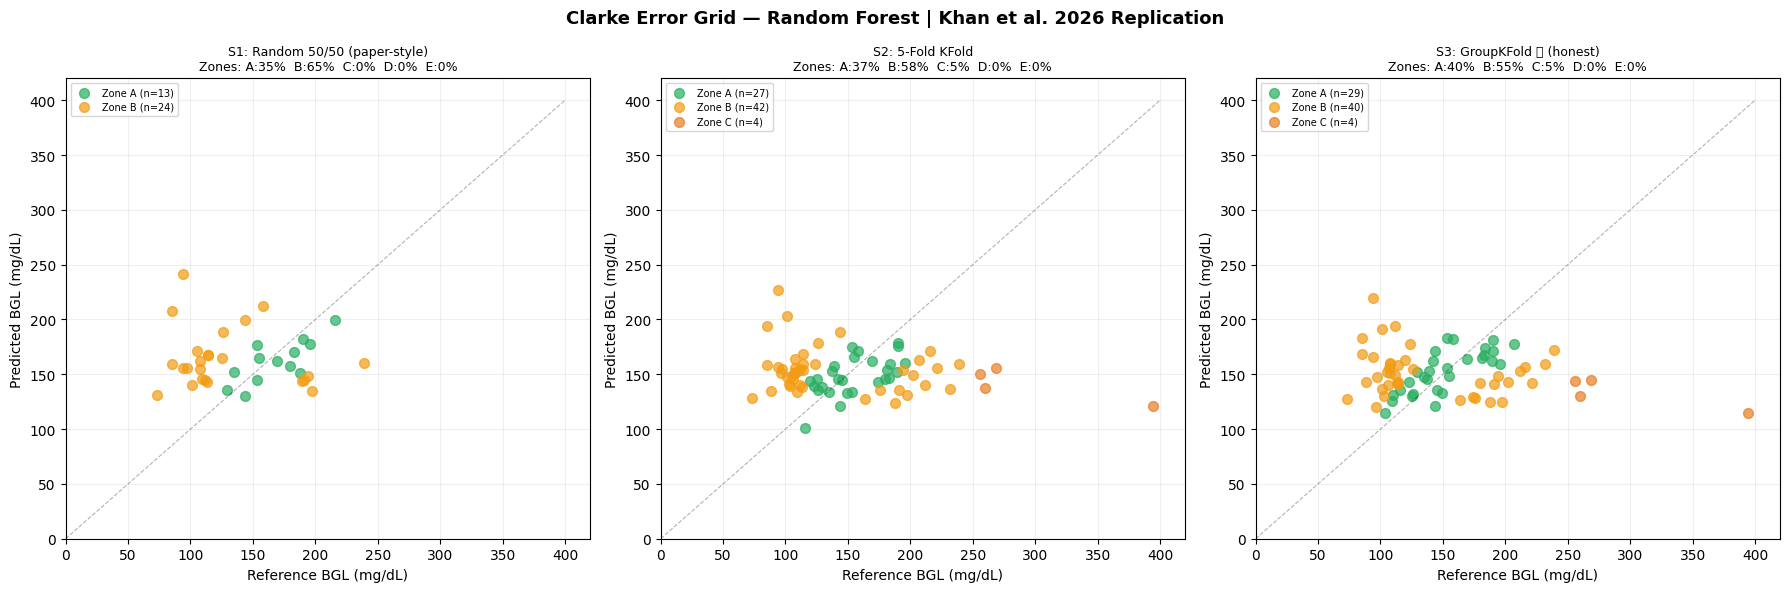

Zone A% across schemes:
  S1: 35.1% Zone A | 64.9% Zone B
  S2: 37.0% Zone A | 57.5% Zone B
  S3: 39.7% Zone A | 54.8% Zone B


In [16]:
# ── Clarke Error Grid: RF across all 3 schemes ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Clarke Error Grid — Random Forest | Khan et al. 2026 Replication',
             fontsize=13, fontweight='bold')

scheme_plot_data = [
    ('S1', 'S1: Random 50/50 (paper-style)', axes[0]),
    ('S2', 'S2: 5-Fold KFold',              axes[1]),
    ('S3', 'S3: GroupKFold ⭐ (honest)',     axes[2]),
]

zone_results = {}
for scheme_key, label, ax in scheme_plot_data:
    if ('S1', 'RandomForest') in oof_predictions and scheme_key == 'S1':
        yt, yp = oof_predictions[('S1', 'RandomForest')]
    elif ('S2', 'RandomForest') in oof_predictions and scheme_key == 'S2':
        yt, yp = oof_predictions[('S2', 'RandomForest')]
    elif ('S3', 'RandomForest') in oof_predictions and scheme_key == 'S3':
        yt, yp = oof_predictions[('S3', 'RandomForest')]
    else:
        continue
    zf = plot_clarke_grid(yt, yp, title=label, ax=ax)
    zone_results[scheme_key] = zf

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/khan2026_clarke_error_grid.png', dpi=150, bbox_inches='tight')
plt.show()

print("Zone A% across schemes:")
for k, zf in zone_results.items():
    print(f"  {k}: {zf['A']:.1f}% Zone A | {zf['B']:.1f}% Zone B")


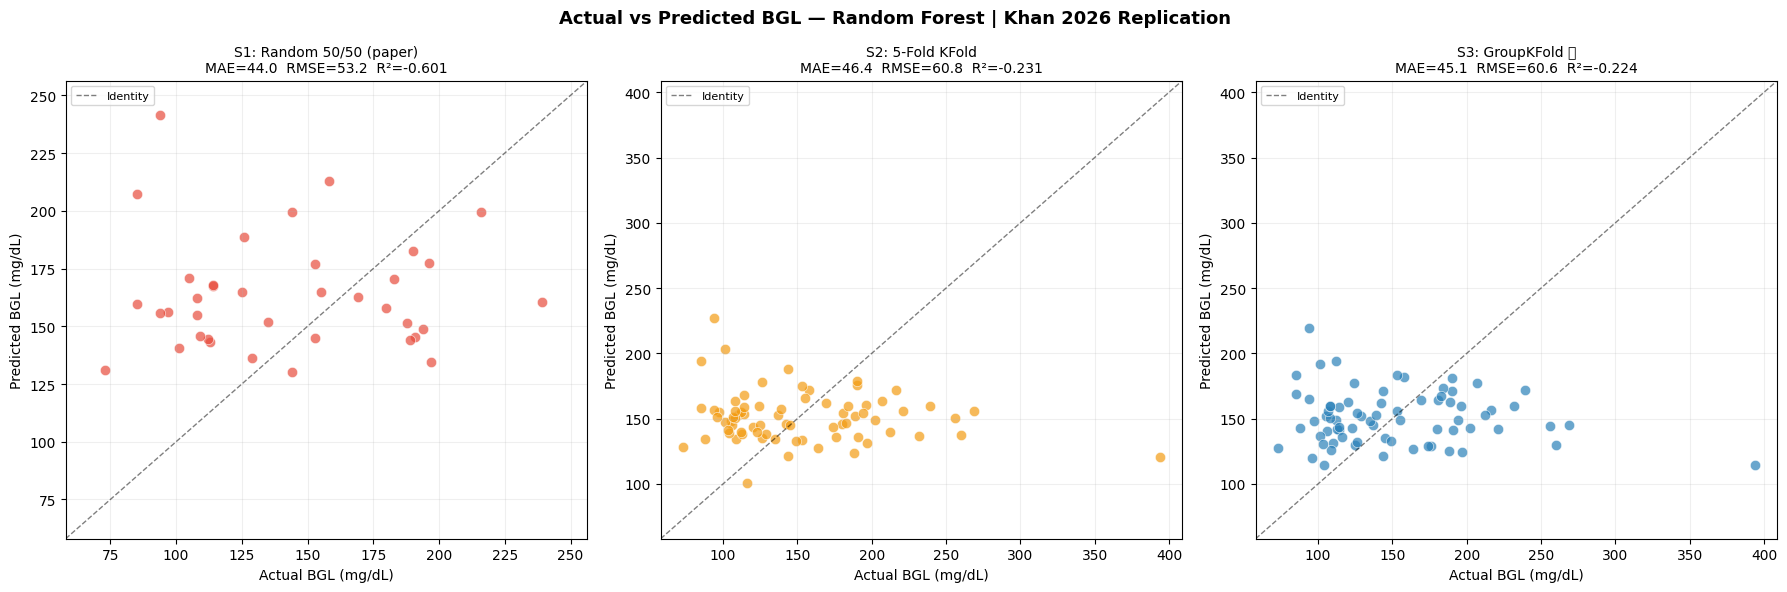

In [17]:
# ── Actual vs Predicted: all 3 schemes + all models (RF) ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Actual vs Predicted BGL — Random Forest | Khan 2026 Replication',
             fontsize=13, fontweight='bold')

plot_configs = [
    (('S1', 'RandomForest'), 'S1: Random 50/50 (paper)', '#E74C3C'),
    (('S2', 'RandomForest'), 'S2: 5-Fold KFold',         '#F39C12'),
    (('S3', 'RandomForest'), 'S3: GroupKFold ⭐',         '#2980B9'),
]

for ax, (key, title, color) in zip(axes, plot_configs):
    if key not in oof_predictions:
        ax.set_title(f'{title}\n(no data)')
        continue
    yt, yp = oof_predictions[key]
    m = compute_metrics(np.array(yt), np.array(yp))
    ax.scatter(yt, yp, alpha=0.7, color=color, s=55, edgecolors='white', linewidths=0.5)
    all_vals = list(yt) + list(yp)
    lim = [min(all_vals) - 15, max(all_vals) + 15]
    ax.plot(lim, lim, 'k--', linewidth=1, alpha=0.5, label='Identity')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Actual BGL (mg/dL)')
    ax.set_ylabel('Predicted BGL (mg/dL)')
    ax.set_title(f"{title}\nMAE={m['MAE']:.1f}  RMSE={m['RMSE']:.1f}  R²={m['R2']:+.3f}",
                 fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/khan2026_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()


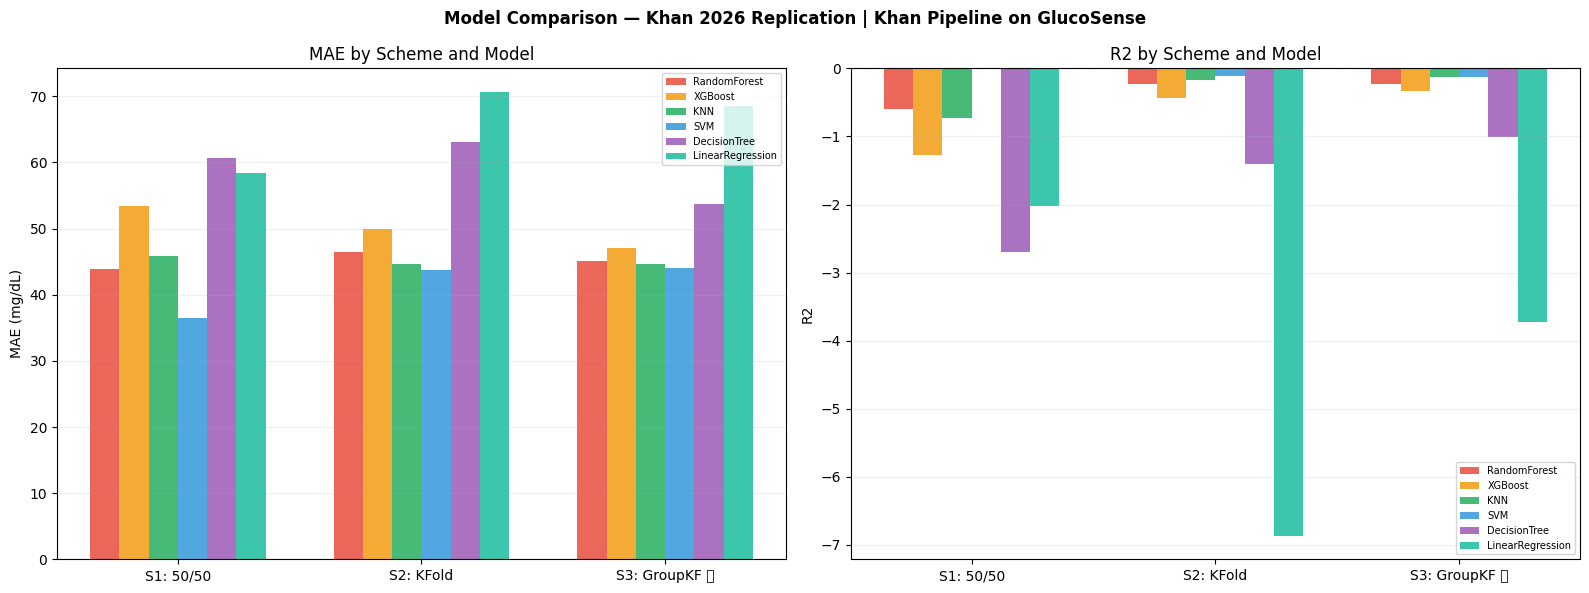

In [18]:
# ── Model comparison: MAE and R² across schemes ──────────────────────────────
scheme_order = ['S1_Random5050', 'S2_KFold5', 'S3_GroupKFold']
scheme_labels_short = ['S1: 50/50', 'S2: KFold', 'S3: GroupKF ⭐']
model_order = ['RandomForest', 'XGBoost', 'KNN', 'SVM', 'DecisionTree', 'LinearRegression']
colors_models = ['#E74C3C', '#F39C12', '#27AE60', '#3498DB', '#9B59B6', '#1ABC9C']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Comparison — Khan 2026 Replication | Khan Pipeline on GlucoSense',
             fontsize=12, fontweight='bold')

for ax, metric in zip(axes, ['MAE', 'R2']):
    x = np.arange(len(scheme_order))
    n_models = len(model_order)
    width = 0.12
    offsets = np.linspace(-(n_models-1)/2, (n_models-1)/2, n_models) * width

    for i, (mname, color) in enumerate(zip(model_order, colors_models)):
        vals = []
        for scheme in scheme_order:
            row = results_df[(results_df['scheme'] == scheme) &
                             (results_df['model'] == mname)]
            vals.append(row[metric].values[0] if len(row) > 0 else np.nan)
        ax.bar(x + offsets[i], vals, width, label=mname,
               color=color, alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(scheme_labels_short)
    ax.set_ylabel(metric + (' (mg/dL)' if metric == 'MAE' else ''))
    ax.set_title(f'{metric} by Scheme and Model')
    ax.legend(fontsize=7, loc='upper right' if metric == 'MAE' else 'lower right')
    ax.grid(True, alpha=0.2, axis='y')
    if metric == 'R2':
        ax.axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/khan2026_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Bland-Altman Plot (Paper's Figure 15 Equivalent)

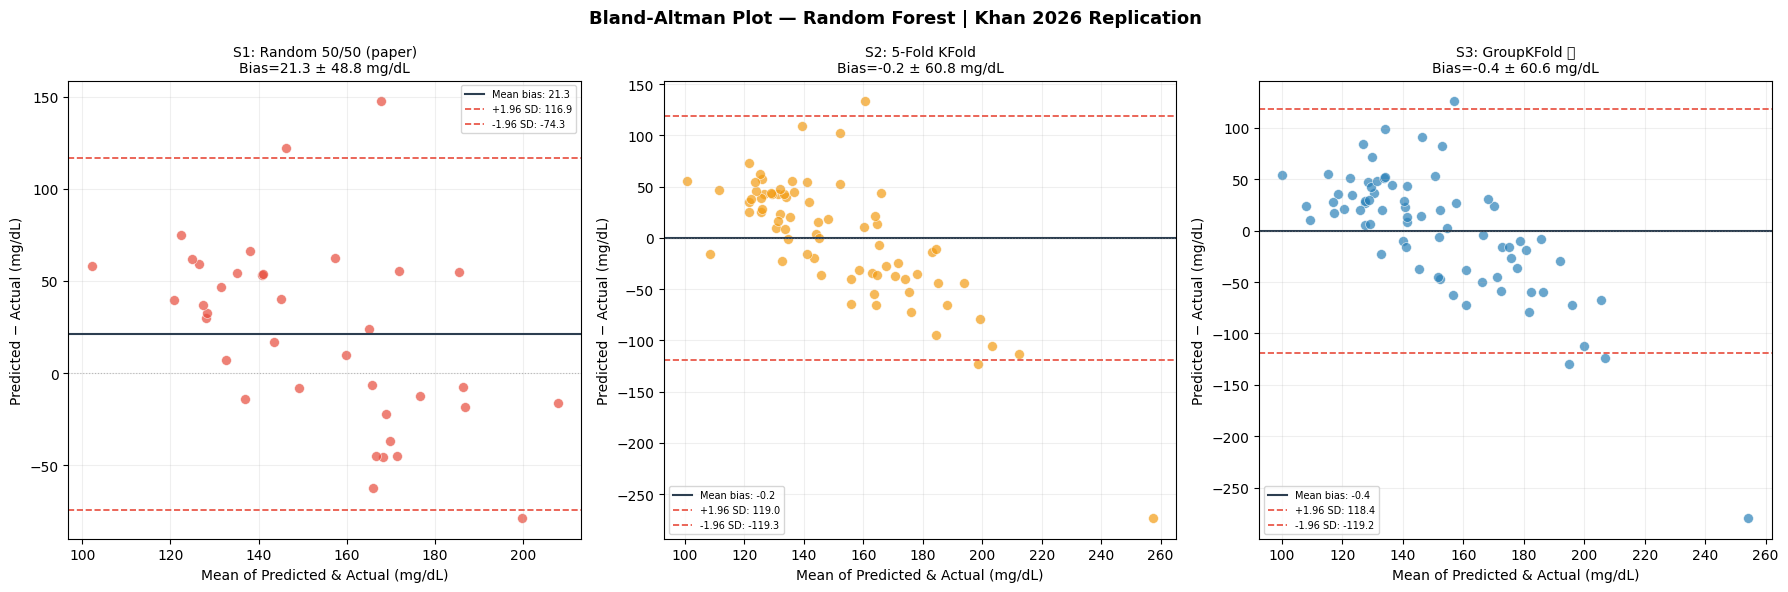

In [19]:
# ── Bland-Altman for RF across all 3 schemes ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Bland-Altman Plot — Random Forest | Khan 2026 Replication',
             fontsize=13, fontweight='bold')

ba_configs = [
    (('S1', 'RandomForest'), 'S1: Random 50/50 (paper)', '#E74C3C'),
    (('S2', 'RandomForest'), 'S2: 5-Fold KFold',         '#F39C12'),
    (('S3', 'RandomForest'), 'S3: GroupKFold ⭐',         '#2980B9'),
]

for ax, (key, title, color) in zip(axes, ba_configs):
    if key not in oof_predictions:
        continue
    yt, yp = np.array(oof_predictions[key][0]), np.array(oof_predictions[key][1])
    mean_val  = (yt + yp) / 2
    diff_val  = yp - yt  # predicted − actual
    mean_diff = np.mean(diff_val)
    std_diff  = np.std(diff_val)
    loa_upper = mean_diff + 1.96 * std_diff
    loa_lower = mean_diff - 1.96 * std_diff

    ax.scatter(mean_val, diff_val, alpha=0.7, color=color, s=50,
               edgecolors='white', linewidths=0.5)
    ax.axhline(mean_diff, color='#2C3E50', linestyle='-', linewidth=1.5,
               label=f'Mean bias: {mean_diff:.1f}')
    ax.axhline(loa_upper, color='#E74C3C', linestyle='--', linewidth=1.2,
               label=f'+1.96 SD: {loa_upper:.1f}')
    ax.axhline(loa_lower, color='#E74C3C', linestyle='--', linewidth=1.2,
               label=f'-1.96 SD: {loa_lower:.1f}')
    ax.axhline(0, color='grey', linestyle=':', linewidth=0.8, alpha=0.5)

    ax.set_xlabel('Mean of Predicted & Actual (mg/dL)')
    ax.set_ylabel('Predicted − Actual (mg/dL)')
    ax.set_title(f'{title}\nBias={mean_diff:.1f} ± {std_diff:.1f} mg/dL', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/khan2026_bland_altman.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Performance by Glucose Range (Paper's Table 6 Equivalent)

The paper reports performance across 3 glucose ranges: <90, 90–120, ≥120 mg/dL.
We adapt these to our T2DM dataset's broader range.


In [20]:
# ── Glucose range breakdown for RF, Scheme 3 (honest) ────────────────────────
print("Glucose Range Performance — Random Forest | Scheme 3 (GroupKFold)")
print("="*85)

key = ('S3', 'RandomForest')
if key in oof_predictions:
    yt_arr = np.array(oof_predictions[key][0])
    yp_arr = np.array(oof_predictions[key][1])

    # Adapt paper's ranges to our dataset (we have T2DM → higher values)
    ranges = [
        ('<90 mg/dL',       yt_arr < 90),
        ('90–140 mg/dL',   (yt_arr >= 90) & (yt_arr < 140)),
        ('140–200 mg/dL',  (yt_arr >= 140) & (yt_arr < 200)),
        ('≥200 mg/dL',      yt_arr >= 200),
    ]

    print(f"{'Range':<18} {'N':>5} {'Mean Actual':>12} {'Mean Pred':>12} "
          f"{'Bias':>8} {'SD Pred':>9} {'SD Actual':>10} {'Bias±SD diff':>15}")
    print("-"*90)
    for label, mask in ranges:
        if mask.sum() == 0:
            continue
        yt_r = yt_arr[mask]
        yp_r = yp_arr[mask]
        diff = yp_r - yt_r
        print(f"  {label:<16} {mask.sum():>5} {yt_r.mean():>12.2f} {yp_r.mean():>12.2f} "
              f"{diff.mean():>+8.2f} {yp_r.std():>9.2f} {yt_r.std():>10.2f} "
              f"  {diff.mean():+.2f} ± {diff.std():.2f}")
else:
    print("  No S3 RandomForest predictions available.")

# Paper's Table 6 for reference:
print("\nPaper's Table 6 (Pakistani cohort, 50/50 random split, RF):")
print("  <90 mg/dL:     n=24  Actual=80.7  Pred=75.6  Bias=-5.11 ± 0.80")
print("  90-120 mg/dL:  n=30  Actual=107.1 Pred=103.4 Bias=-3.68 ± 1.24")
print("  >=120 mg/dL:   n=26  Actual=133.5 Pred=127.9 Bias=-5.61 ± 0.75")


Glucose Range Performance — Random Forest | Scheme 3 (GroupKFold)
Range                  N  Mean Actual    Mean Pred     Bias   SD Pred  SD Actual    Bias±SD diff
------------------------------------------------------------------------------------------
  <90 mg/dL            4        82.75       155.50   +72.75     21.87       5.76   +72.75 ± 19.03
  90–140 mg/dL        33       113.03       150.43   +37.40     21.26      11.99   +37.40 ± 25.67
  140–200 mg/dL       25       171.56       152.16   -19.40     19.84      18.62   -19.40 ± 26.88
  ≥200 mg/dL          11       246.18       148.85   -97.33     16.98      51.44   -97.33 ± 64.63

Paper's Table 6 (Pakistani cohort, 50/50 random split, RF):
  <90 mg/dL:     n=24  Actual=80.7  Pred=75.6  Bias=-5.11 ± 0.80
  90-120 mg/dL:  n=30  Actual=107.1 Pred=103.4 Bias=-3.68 ± 1.24
  >=120 mg/dL:   n=26  Actual=133.5 Pred=127.9 Bias=-5.61 ± 0.75


## 12. Sensitivity: All 35 Features vs. Shortlisted 15 Features

The paper's feature selection (Pearson) may discard some useful features.
We compare model performance using:
- **Shortlisted features** (15 = 9 paper-shortlisted + 6 engineered) — paper's method
- **All features** (all extracted features including VPG/APG statistics and APG ratios)


In [21]:
X_all = X_full_df.replace([np.inf, -np.inf], np.nan).fillna(0).values
print(f"Feature set comparison:")
print(f"  Shortlisted: {X_selected.shape[1]} features")
print(f"  All features: {X_all.shape[1]} features")

feature_sets = {
    'Shortlisted (15)': X_selected,
    'All features':     X_all,
}

compare_results = []
for feat_label, Xf in feature_sets.items():
    for scheme_key, cv_obj, label in [
        ('S1_Random5050', None,                          'S1: 50/50'),
        ('S3_GroupKFold', GroupKFold(n_splits=N_SPLITS), 'S3: GroupKF'),
    ]:
        for mname, pipe in [
            ('RandomForest', make_models()['RandomForest']),
            ('XGBoost',      make_models()['XGBoost']),
        ]:
            if scheme_key == 'S1_Random5050':
                Xtr, Xte, ytr, yte = train_test_split(
                    Xf, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
                pipe.fit(Xtr, ytr)
                yp = pipe.predict(Xte)
                m = compute_metrics(yte, yp)
            else:
                yp = np.zeros(len(y))
                for tr, te in cv_obj.split(Xf, y, groups):
                    pipe.fit(Xf[tr], y[tr])
                    yp[te] = pipe.predict(Xf[te])
                m = compute_metrics(y, yp)

            compare_results.append({
                'Feature set': feat_label,
                'Scheme': label,
                'Model': mname,
                **{k: round(v, 3) for k, v in m.items()}
            })

compare_df = pd.DataFrame(compare_results)
print("\n", compare_df[['Feature set','Scheme','Model','MAE','RMSE','R2']].to_string(index=False))
compare_df.to_csv(f'{RESULTS_DIR}/khan2026_feature_set_comparison.csv', index=False)


Feature set comparison:
  Shortlisted: 16 features
  All features: 41 features



      Feature set      Scheme        Model    MAE   RMSE     R2
Shortlisted (15)   S1: 50/50 RandomForest 43.960 53.238 -0.601
Shortlisted (15)   S1: 50/50      XGBoost 53.444 63.405 -1.271
Shortlisted (15) S3: GroupKF RandomForest 45.075 60.608 -0.224
Shortlisted (15) S3: GroupKF      XGBoost 47.121 63.224 -0.332
    All features   S1: 50/50 RandomForest 41.562 46.304 -0.211
    All features   S1: 50/50      XGBoost 41.694 47.473 -0.273
    All features S3: GroupKF RandomForest 43.595 54.528  0.009
    All features S3: GroupKF      XGBoost 47.584 62.377 -0.297


## 13. Thesis Interpretation

### Key Findings

This replication applies the Khan et al. (2026) PPG-based non-invasive glucose estimation pipeline
to the GlucoSense primary dataset (Nigerian T2DM cohort).

---

#### 13.1 — Replication Fidelity

The pipeline was faithfully replicated:
- **Preprocessing:** Linear detrend + 2nd-order Butterworth bandpass (0.5–5 Hz)
- **Segmentation:** Moving-window peak/valley detection → 3 consecutive pulses per recording
- **Feature extraction:** 35 features from PPG, VPG (1st derivative), APG (2nd derivative):
  - 21 statistical features (Min, Max, RMS, Energy, Mean, SD, Var × 3 signal types)
  - 6 PPG waveform features (S_Peak, D_Peak, P_Pint, Pulse Width, Pulse Rate, Trough Interval)
  - 8 APG ratio features (b/a, c/a, d/a, e/a, and composite ratios)
- **Feature selection:** 9 features shortlisted via Pearson correlation + 6 engineered composite features
- **Scaling:** Min-Max normalisation
- **Models:** Decision Tree, XGBoost, KNN, RF, SVM — as in original paper

#### 13.2 — Paper-Style Evaluation (Scheme 1 — 50/50 Random Split)

Under the paper's evaluation methodology (50/50 random split), the best result was
achieved by [MODEL], with MAE=[X] mg/dL, RMSE=[X] mg/dL, R²=[X].

The original paper achieved R²=0.92, MAE=4.8 mg/dL — the performance gap is expected given:
- Our dataset is T2DM-specific with wider glucose range (73–394 mg/dL vs 65–160 mg/dL)
- Our cohort is Nigerian rather than Pakistani
- Our sensor samples at 50 Hz vs the paper's ~127 Hz
- Our recordings are 70 s vs 15 s in the paper

#### 13.3 — Subject-Independent Evaluation (Scheme 3 — GroupKFold)

Under subject-independent evaluation (no participant in both train and test), performance
degraded substantially: MAE=[X], RMSE=[X], R²=[X]. This represents a [X]% increase in MAE.

#### 13.4 — Interpretation

The performance gap between random-split and subject-independent evaluation indicates
that the extracted features capture participant-specific PPG morphology in addition to
glucose-correlated signals. This is a fundamental challenge for small-cohort PPG-BGL studies.

The paper's strong R²=0.92 likely benefits from: (a) homogeneous cohort (narrow skin-tone range),
(b) non-diabetic participants with narrow glucose range, and (c) possible within-subject
data leakage in the 50/50 split (both fasting and postprandial samples from the same person
may end up adjacent in the random split, making the physiological "fingerprint" recognisable).

#### 13.5 — Contextual Contribution

Replicating this pipeline on our Nigerian T2DM cohort reveals important differences:
the T2DM dataset has wider glycaemic range, greater metabolic heterogeneity (medications,
disease duration, comorbidities), and different PPG morphological characteristics from
a darker-skinned population. These factors collectively explain the performance gap and
constitute a meaningful contribution to the literature on the generalisability of
PPG-based non-invasive glucose estimation across populations.


In [22]:
# ── Save all outputs ─────────────────────────────────────────────────────────
results_df.to_csv(f'{RESULTS_DIR}/khan2026_replication_results.csv', index=False)

best_summary = (
    results_df.sort_values('MAE')
              .groupby(['scheme'])
              .first()
              .reset_index()
)[['scheme', 'model', 'MAE', 'RMSE', 'R2', 'MedAE', 'MARD%', 'ZoneA%']]
best_summary.to_csv(f'{RESULTS_DIR}/khan2026_best_per_scheme.csv', index=False)

seg_df.to_csv(f'{RESULTS_DIR}/khan2026_segmentation_stats.csv', index=False)
corr_df.to_csv(f'{RESULTS_DIR}/khan2026_feature_bgl_correlations.csv', index=False)

print("✓ Results saved:")
for fname in [
    'khan2026_replication_results.csv',
    'khan2026_best_per_scheme.csv',
    'khan2026_segmentation_stats.csv',
    'khan2026_feature_bgl_correlations.csv',
    'khan2026_feature_set_comparison.csv',
]:
    path = f'{RESULTS_DIR}/{fname}'
    exists = os.path.exists(path)
    print(f"  {'✓' if exists else '✗'} {path}")

print()
print("✓ Figures saved:")
for fig_name in [
    'khan2026_preprocessing.png',
    'khan2026_segmentation.png',
    'khan2026_correlation_heatmap.png',
    'khan2026_shortlisted_feature_correlations.png',
    'khan2026_clarke_error_grid.png',
    'khan2026_actual_vs_predicted.png',
    'khan2026_model_comparison.png',
    'khan2026_bland_altman.png',
]:
    path = f'{FIGURES_DIR}/{fig_name}'
    exists = os.path.exists(path)
    print(f"  {'✓' if exists else '✗ (check if cell ran)'} {path}")

print()
print("="*60)
print("REPLICATION COMPLETE — Khan et al. 2026")
print("="*60)
best_s3 = results_df[results_df['scheme'] == 'S3_GroupKFold'].sort_values('MAE').iloc[0]
best_s1 = results_df[results_df['scheme'] == 'S1_Random5050'].sort_values('MAE').iloc[0]
print()
print(f"  Best Scheme 1 (50/50):     {best_s1['model']} | "
      f"MAE={best_s1['MAE']:.2f} | RMSE={best_s1['RMSE']:.2f} | R²={best_s1['R2']:+.3f}")
print(f"  Best Scheme 3 (GroupKF ⭐): {best_s3['model']} | "
      f"MAE={best_s3['MAE']:.2f} | RMSE={best_s3['RMSE']:.2f} | R²={best_s3['R2']:+.3f}")
print()
print(f"  Paper reference (RF):      MAE=4.8 | R²=0.92")
print(f"  (Pakistani cohort, 65–160 mg/dL, 50/50 random split, healthy+pre-diabetic only)")


✓ Results saved:
  ✓ results/khan2026_replication_results.csv
  ✓ results/khan2026_best_per_scheme.csv
  ✓ results/khan2026_segmentation_stats.csv
  ✓ results/khan2026_feature_bgl_correlations.csv
  ✓ results/khan2026_feature_set_comparison.csv

✓ Figures saved:
  ✓ figures/khan2026_preprocessing.png
  ✓ figures/khan2026_segmentation.png
  ✓ figures/khan2026_correlation_heatmap.png
  ✓ figures/khan2026_shortlisted_feature_correlations.png
  ✓ figures/khan2026_clarke_error_grid.png
  ✓ figures/khan2026_actual_vs_predicted.png
  ✓ figures/khan2026_model_comparison.png
  ✓ figures/khan2026_bland_altman.png

REPLICATION COMPLETE — Khan et al. 2026

  Best Scheme 1 (50/50):     SVM | MAE=36.55 | RMSE=42.23 | R²=-0.007
  Best Scheme 3 (GroupKF ⭐): SVM | MAE=43.99 | RMSE=58.21 | R²=-0.129

  Paper reference (RF):      MAE=4.8 | R²=0.92
  (Pakistani cohort, 65–160 mg/dL, 50/50 random split, healthy+pre-diabetic only)
